## Herencia

### Ejemplo 1

@startuml
class Lanzamiento {
  + titulo: str
  + artista: str
  + year: int
  - _reproducciones: int
  + reproducir(num: int)
  + obtener_info(): str
}

class Sencillo {
  + es_remix: bool
  + obtener_info(): str
}

class Album {
  + num_pistas: int
  + promocionar()
}

Lanzamiento <|-- Sencillo
Lanzamiento <|-- Album
@enduml

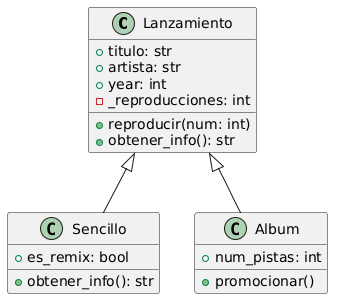

In [36]:
class Lanzamiento:
    def __init__(self, titulo: str, artista: str, year: int) -> None:
        self.titulo: str = titulo
        self.artista: str = artista
        self.year: int = year
        self._reproducciones: int = 0

    def reproducir(self, num: int) -> None:
        self._reproducciones += num

    def obtener_info(self) -> str:
        return f"'{self.titulo}' de {self.artista} ({self.year}) - Streams: {self._reproducciones}"

class Sencillo(Lanzamiento):
    def __init__(self, titulo: str, artista: str, year: int, es_remix: bool = False) -> None:
        super().__init__(titulo=titulo, artista=artista, year=year)
        self.es_remix: bool = es_remix

    def obtener_info(self) -> str:
        version = " (Remix)" if self.es_remix else " (Original Single)"
        return super().obtener_info() + version

class Album(Lanzamiento):
    def __init__(self, titulo: str, artista: str, year: int, num_pistas: int) -> None:
        super().__init__(titulo=titulo, artista=artista, year=year)
        self.num_pistas: int = num_pistas

    def promocionar(self) -> None:
        if self._reproducciones > 1000:
            print(f"¡Promocionando álbum destacado! '{self.titulo}' con {self.num_pistas} canciones.")
        else:
            print(f"El álbum '{self.titulo}' necesita más streams antes de la campaña de marketing.")

In [37]:
single = Sencillo(titulo="Amarte Más No Pude", artista="Luisster", year=2026, es_remix=True)
album = Album(titulo="Caribe Nocturno", artista="Varios Artistas", year=2025, num_pistas=12)

catalogo: list[Lanzamiento] = [single, album]

for release in catalogo:
    release.reproducir(num=1500)
    print(release.obtener_info())

album.promocionar()

'Amarte Más No Pude' de Luisster (2026) - Streams: 1500 (Remix)
'Caribe Nocturno' de Varios Artistas (2025) - Streams: 1500
¡Promocionando álbum destacado! 'Caribe Nocturno' con 12 canciones.


### Ejemplo 2: Herencia múltiple

@startuml
class Lanzamiento {
  + titulo: str
  + artista: str
  + year: int
  # _reproducciones: int
  + reproducir(num: int): void
  + obtener_info(): str
}

class Monetizable {
  + tarifa_stream: float
  + calcular_regalias(reproducciones: int): float
}

class Sencillo {
  + es_remix: bool
  + obtener_info(): str
}

class AlbumMonetizable {
  + num_pistas: int
  + promocionar(): void
}

Lanzamiento <|-- Sencillo
Lanzamiento <|-- AlbumMonetizable
Monetizable <|-- AlbumMonetizable
@enduml

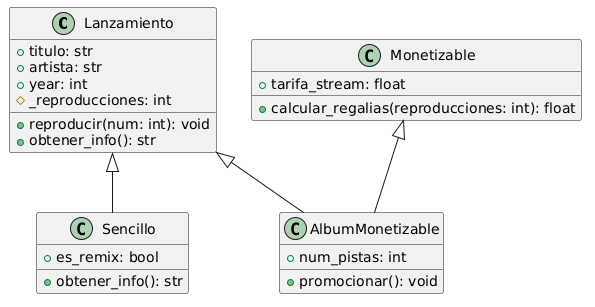

In [38]:
class Lanzamiento:
    def __init__(self, titulo: str, artista: str, year: int, **kwargs) -> None:
        super().__init__(**kwargs)
        self.titulo: str = titulo
        self.artista: str = artista
        self.year: int = year
        self._reproducciones: int = 0

    def reproducir(self, num: int) -> None:
        self._reproducciones += num

    def obtener_info(self) -> str:
        return f"'{self.titulo}' de {self.artista} ({self.year}) - Streams: {self._reproducciones}"


class Monetizable:
    """Clase base adicional para productos que generan regalías y licencias."""
    def __init__(self, tarifa_stream: float = 0.004, **kwargs) -> None:
        super().__init__(**kwargs)
        self.tarifa_stream: float = tarifa_stream

    def calcular_regalias(self, reproducciones: int) -> float:
        return round(reproducciones * self.tarifa_stream, 2)


class Sencillo(Lanzamiento):
    def __init__(self, es_remix: bool = False, **kwargs) -> None:
        super().__init__(**kwargs)
        self.es_remix: bool = es_remix

    def obtener_info(self) -> str:
        version = " (Remix)" if self.es_remix else " (Original Single)"
        return super().obtener_info() + version


class AlbumMonetizable(Lanzamiento, Monetizable):
    """Clase que utiliza HERENCIA MÚLTIPLE (Lanzamiento + Monetizable)"""
    def __init__(self, num_pistas: int, **kwargs) -> None:
        super().__init__(**kwargs)
        self.num_pistas: int = num_pistas

    def promocionar(self) -> None:
        if self._reproducciones > 1000:
            regalias = self.calcular_regalias(self._reproducciones)
            print(f"¡Promocionando '{self.titulo}'! ({self.num_pistas} pistas) - Regalías acumuladas: ${regalias} USD")
        else:
            print(f"El álbum '{self.titulo}' necesita más de 1000 streams para iniciar campaña.")




In [39]:
single = Sencillo(titulo="Amarte Más No Pude", artista="Luisster", year=2026, es_remix=True)
album = AlbumMonetizable(titulo="Caribe Nocturno", artista="Varios Artistas", year=2025, num_pistas=12, tarifa_stream=0.005)

catalogo: list[Lanzamiento] = [single, album]

for release in catalogo:
    release.reproducir(num=1500)
    print(release.obtener_info())

print("-" * 50)
album.promocionar()

'Amarte Más No Pude' de Luisster (2026) - Streams: 1500 (Remix)
'Caribe Nocturno' de Varios Artistas (2025) - Streams: 1500
--------------------------------------------------
¡Promocionando 'Caribe Nocturno'! (12 pistas) - Regalías acumuladas: $7.5 USD
